<a href="https://colab.research.google.com/github/karsarobert/DeepLearning2026/blob/main/deep_learning_lab_3_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Practical Session

## Practical Session 3: Gradient Descent
### September 21, 2026

# Linear Regression
## Predicting Student Exam Scores Based on Study Hours

Source: https://github.com/kaustubholpadkar/

### 1. Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### 2. Read Dataset

In [ ]:
data = np.genfromtxt('https://raw.githubusercontent.com/kaustubholpadkar/Linear_Regression-Gradient_Descent-Octave/master/data.csv', delimiter=',')

In [ ]:
# Dataset shape: 100 training data records
data.shape

(100, 2)

In [ ]:
# First 5 rows: first column is feature X (study hours), second column is target y (exam score)
data[:5, :]

array([[32.50234527, 31.70700585],
       [53.42680403, 68.77759598],
       [61.53035803, 62.5623823 ],
       [47.47563963, 71.54663223],
       [59.81320787, 87.23092513]])

### 3. Separate Data into Feature (X) and Target (Y)

In [ ]:
X = data[:, 0]
Y = data[:, 1]

### 4. Visualize the Data

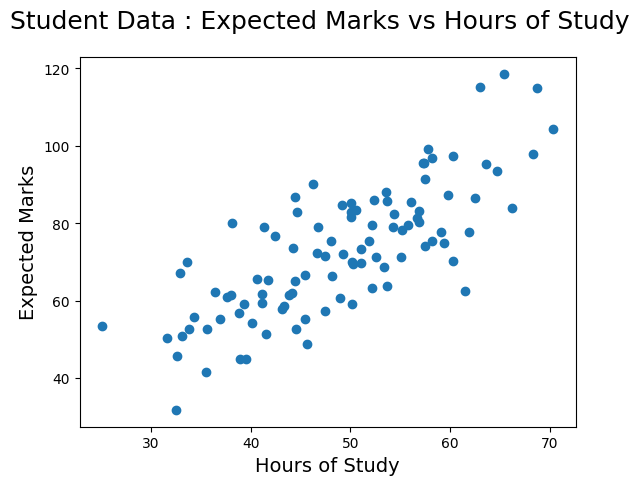

In [ ]:
fig = plt.figure()
plt.scatter(X, Y)
fig.suptitle('Student Data : Expected Marks vs Hours of Study', fontsize=18)
plt.xlabel('Hours of Study', fontsize=14)
plt.ylabel('Expected Marks', fontsize=14)
plt.show()

### 5. Hyperparameters

In [ ]:
learning_rate = 0.0001
max_iteration = 50

### 6. Model Parameters

In [ ]:
m = 1
b = 1

### 7. Hypothesis Function

In [ ]:
def h(m, b, X):
    return m * X + b

### 8. Cost / Loss Function (Mean Squared Error)

In [ ]:
def loss(m, b, X, Y):
    return np.average(np.square(Y - h(m, b, X))) / 2

### 9. Calculate Analytical Gradients

In [ ]:
def gradient(m, b, X, Y):
    # Partial derivative of the loss function with respect to m
    # We use average because we are computing across the entire batch
    dm = - np.average((Y - h(m, b, X)) * X)
    # Partial derivative with respect to b
    db = - np.average(Y - h(m, b, X))
    return (dm, db)

In [ ]:

dm, db = gradient(m, b, X, Y)


In [ ]:
print(dm, db)

-645.6916338472439 -12.954463330749475


In [ ]:
m -= learning_rate * dm
b -= learning_rate * db


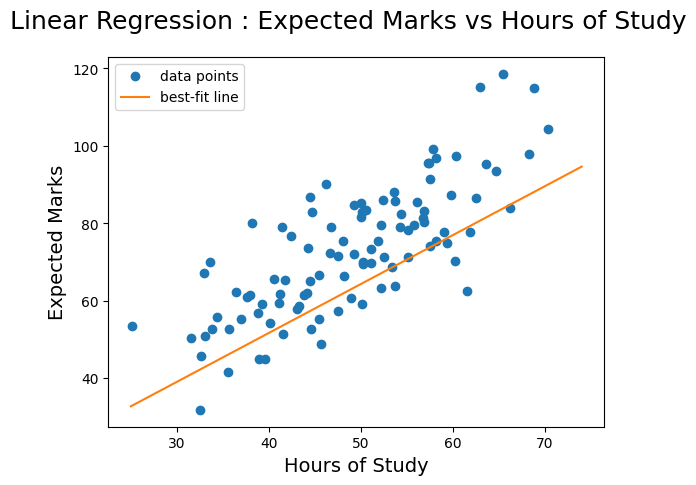

In [ ]:
fig = plt.figure()

# Generate data for plotting the fitted line
x = np.arange(25, 75)
y = [m * x_i + b for x_i in x]

# Plot original data points and best-fit line
plt.plot(X, Y, 'o', x, y, '-')
plt.legend(loc='upper left', labels=['data points', 'best-fit line'])

fig.suptitle('Linear Regression : Expected Marks vs Hours of Study', fontsize=18)
plt.xlabel('Hours of Study', fontsize=14)
plt.ylabel('Expected Marks', fontsize=14)
plt.show()

In [ ]:
print(Y[:3], h(m, b, X)[:3])

[31.70700585 68.77759598 62.5623823 ] [33.50234527 54.42680403 62.53035803]


### 10. Gradient Descent Optimization Loop

In [ ]:
def gradient_descent(m, b, X, Y, learning_rate, max_iteration):
    for i in range(max_iteration):
        dm, db = gradient(m, b, X, Y)
        m -= learning_rate * dm
        b -= learning_rate * db
        if i % 10 == 0:
            # Log iteration index and current loss value every 10 steps
            print('iteration : ', i, ' loss : ', loss(m, b, X, Y))
    return (m, b)

### 11. Train Model

In [ ]:
m, b = gradient_descent(m, b, X, Y, learning_rate, max_iteration)

iteration :  0  loss :  204.50666115574057
iteration :  10  loss :  56.52985181213651
iteration :  20  loss :  56.05030590326913
iteration :  30  loss :  56.04868285547168
iteration :  40  loss :  56.04860838575527


### 12. Optimal Parameter Values Learned by Model

In [ ]:
m, b

(np.float64(1.4596336737329105), np.float64(1.0103518029193468))

### 13. Visualize the Fitted Regression Line

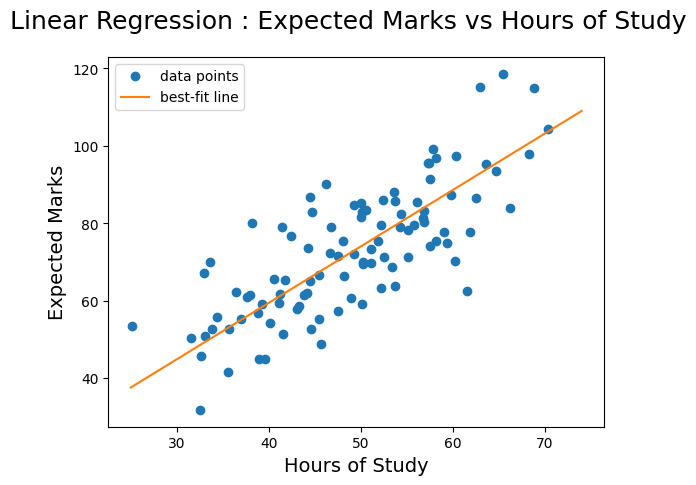

In [ ]:
fig = plt.figure()

# Generate data for plotting the fitted line
x = np.arange(25, 75)
y = [m * x_i + b for x_i in x]

# Plot original data points and best-fit line
plt.plot(X, Y, 'o', x, y, '-')
plt.legend(loc='upper left', labels=['data points', 'best-fit line'])

fig.suptitle('Linear Regression : Expected Marks vs Hours of Study', fontsize=18)
plt.xlabel('Hours of Study', fontsize=14)
plt.ylabel('Expected Marks', fontsize=14)
plt.show()